In [4]:
# Retail Demand Forecasting - Exploratory Data Analysis (EDA)

import pandas as pd

train = pd.read_csv("/content/train - Walmart Sales Forecast.csv")
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
# Dataset contains weekly sales by store and department
# Target variable: Weekly_Sales
# Change Date
train['Date'] = pd.to_datetime(train['Date'])

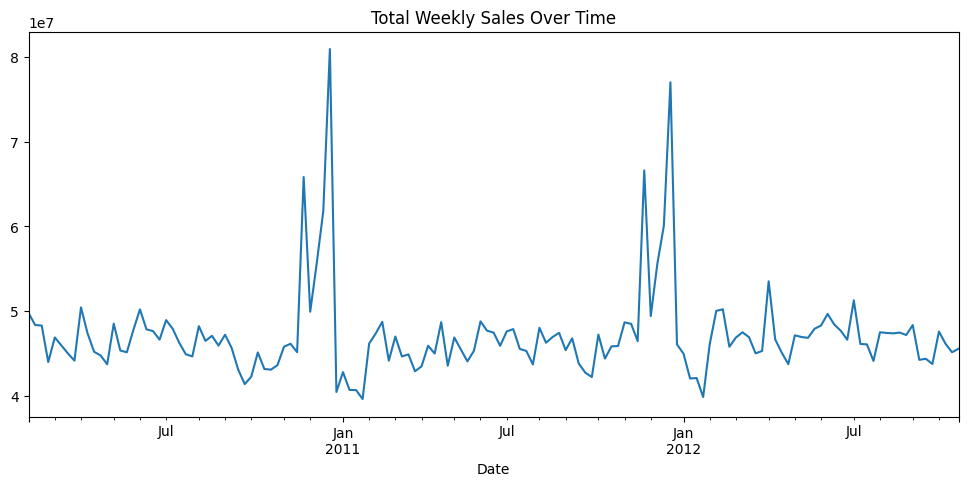

In [6]:
# Sales Over Time (Key Chart)//Évolution des ventes (GRAPHIQUE CLÉ)
import matplotlib.pyplot as plt

sales_trend = train.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,5))
sales_trend.plot()
plt.title("Total Weekly Sales Over Time")
plt.show()

In [7]:
# Insights:
# Sales show clear temporal fluctuations with recurring peaks
# Significant spikes are observed around year-end periods, likely linked to major holidays (e.g., Christmas)
# This indicates strong seasonality in demand
# Incorporating time-based features (e.g., month, holidays) will be critical for accurate forecasting

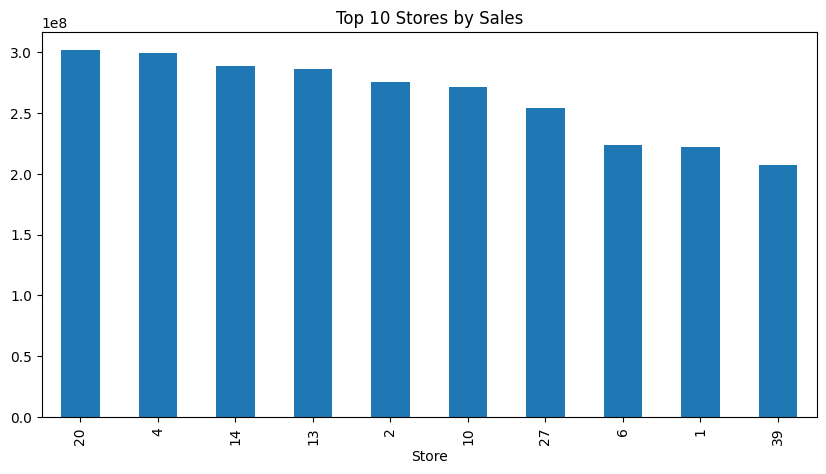

In [8]:
# Compare shops//Comparer les magasins
top_stores = train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

top_stores.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Stores by Sales")
plt.show()

In [9]:
# Sales are highly concentrated among a small number of stores
# Top-performing stores generate significantly higher revenue than the rest
# This suggests potential differences in location, customer demand, or store capacity
# Opportunity: Investigate best-performing stores to replicate success across others

In [10]:
# Is there a holiday effect?//Y a-t-il un effet lié aux vacances ?
train.groupby('IsHoliday')['Weekly_Sales'].mean()

,Weekly_Sales
IsHoliday,
False,15901.445069
True,17035.823187


In [11]:
# Insights:
# Sales are higher during holiday periods compared to non-holiday weeks
# This confirms a positive holiday effect on demand
# Holidays are a key driver of revenue spikes and should be considered in forecasting models
# Business implication: inventory and staffing should be increased ahead of holiday periods

In [12]:
# Feature Engineering//ingénierie des caractéristiques
# 1. Create time features
# Time-based features
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Week'] = train['Date'].dt.isocalendar().week.astype(int)

In [13]:
# 💡 Why?
# 👉 Because I saw the following in EDA:
# seasonality
# holiday effect
# 💥 Now I neet to turn these into useful variables

In [15]:
# 2. Add shop details//Ajouter les informations relatives au magasin
stores = pd.read_csv("stores - Walmart Sales Forecast.csv")
train = train.merge(stores, on='Store', how='left')
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Type,Size
0,1,1,2010-02-05,24924.50,False,2010,2,5,A,151315
1,1,1,2010-02-12,46039.49,True,2010,2,6,A,151315
2,1,1,2010-02-19,41595.55,False,2010,2,7,A,151315
3,1,1,2010-02-26,19403.54,False,2010,2,8,A,151315
4,1,1,2010-03-05,21827.90,False,2010,3,9,A,151315


In [ ]:
# Added store-level features (Type and Size)
# These variables capture structural differences between stores and may help explain variations in sales performance

In [16]:
# Validation
# 👉 to check that:
# each store has a unique type/size
# the merge was successful
train[['Store', 'Type', 'Size']].drop_duplicates().head()

,Store,Type,Size
0,1,A,151315
10244,2,A,202307
20482,3,B,37392
29518,4,A,205863
39790,5,B,34875


In [18]:
# 3. Merge with external features//Fusionner avec des fonctionnalités externes
features = pd.read_csv("features - Walmart Sales Forecast.csv")
# Fix date format: Ensure consistent datetime format before merging datasets
features['Date'] = pd.to_datetime(features['Date'])
# Merge
train = train.merge(features, on=['Store', 'Date'], how='left')
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Year,Month,Week,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,2010,2,5,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,2010,2,6,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,2010,2,7,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,2010,2,8,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,2010,3,9,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [19]:
# 4. Handling missing values//Gérer les valeurs manquantes
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday_x,0
Year,0
Month,0
Week,0
Type,0
Size,0


In [20]:
# Rule:
# MarkDowns → replace with 0
# (because no promotion = 0 impact)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

train[markdown_cols] = train[markdown_cols].fillna(0)

In [21]:
# Cleaning Validation
# # Missing values in markdowns are assumed to indicate no promotion activity
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday_x,0
Year,0
Month,0
Week,0
Type,0
Size,0
